In [27]:
# Step 0: Install / import
!pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [28]:
# ── Step 1: Load dataset ─────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # upload Coronary_heart_risk_study.csv

df = pd.read_csv('Coronary_heart_risk_study.csv')
print(f"Original shape: {df.shape}")

Saving Coronary_heart_risk_study.csv to Coronary_heart_risk_study (2).csv
Original shape: (4240, 16)


In [29]:
# ── Step 2: Fix data types ────────────────────────────────────
df['education'] = df['education'].astype('Int64')  # Int64 supports NaN

In [30]:
# ── Step 3: Handle logical inconsistency ─────────────────────
# Smokers with cigsPerDay = 0 or NaN → impute with median of other smokers
smoker_median_cigs = df.loc[
    (df['currentSmoker'] == 1) & (df['cigsPerDay'] > 0), 'cigsPerDay'
].median()

mask = (df['currentSmoker'] == 1) & (
    df['cigsPerDay'].isna() | (df['cigsPerDay'] == 0)
)
df.loc[mask, 'cigsPerDay'] = smoker_median_cigs
print(f"Fixed {mask.sum()} smoker rows → cigsPerDay set to {smoker_median_cigs}")

Fixed 29 smoker rows → cigsPerDay set to 20.0


In [31]:
# ── Step 4: Impute missing values ────────────────────────────
continuous_cols = ['cigsPerDay', 'totChol', 'sysBP', 'diaBP',
                   'BMI', 'heartRate', 'glucose']
categorical_cols = ['education', 'BPMeds']

median_imputer = SimpleImputer(strategy='median')
df[continuous_cols] = median_imputer.fit_transform(df[continuous_cols])

mode_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = mode_imputer.fit_transform(df[categorical_cols])

# Cast after imputation (imputer returns floats)
df['BPMeds'] = df['BPMeds'].astype(int)
df['education'] = df['education'].astype(int)

print(f"Missing values after imputation:\n{df.isnull().sum()}")

Missing values after imputation:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [32]:
# ── Step 5: Outlier capping (IQR method) ─────────────────────
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col}: capped {n} values → [{lower:.1f}, {upper:.1f}]")
    return df

outlier_cols = ['cigsPerDay', 'totChol', 'sysBP', 'diaBP',
                'BMI', 'heartRate', 'glucose']

print("\nCapping outliers:")
for col in outlier_cols:
    df = cap_outliers(df, col)


Capping outliers:
  cigsPerDay: capped 12 values → [-30.0, 50.0]
  totChol: capped 57 values → [122.0, 346.0]
  sysBP: capped 126 values → [76.5, 184.5]
  diaBP: capped 77 values → [52.5, 112.5]
  BMI: capped 97 values → [15.6, 35.5]
  heartRate: capped 76 values → [45.5, 105.5]
  glucose: capped 262 values → [52.5, 104.5]


In [33]:
from google.colab import files
df_final.to_csv('coronary_preprocessed.csv', index=False)
files.download('coronary_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# ── Step 6: Split features and target ────────────────────────
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

In [35]:
# Step 7: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
# Step 8: Scale continuous features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [37]:
# Step 9: Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE: {y_test.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train).value_counts().to_dict()}")




Before SMOTE: {0: 719, 1: 129}
After SMOTE: {0: 2877, 1: 2877}


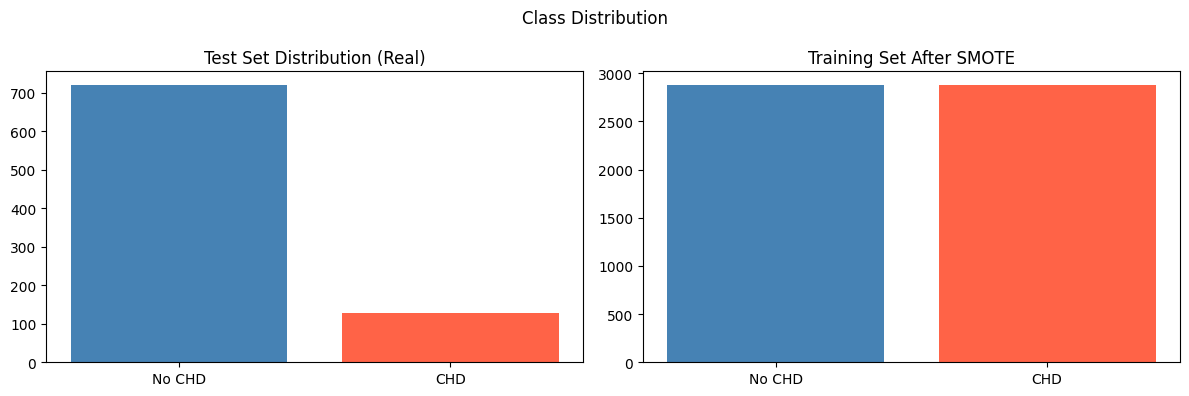

In [38]:
# Step 10: Sanity check plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE (original training distribution)
axes[0].bar(['No CHD', 'CHD'], y_test.value_counts().sort_index(),
            color=['steelblue', 'tomato'])
axes[0].set_title('Test Set Distribution (Real)')

# After SMOTE (balanced training data)
axes[1].bar(['No CHD', 'CHD'], pd.Series(y_train).value_counts().sort_index(),
            color=['steelblue', 'tomato'])
axes[1].set_title('Training Set After SMOTE')

plt.suptitle('Class Distribution')
plt.tight_layout()
plt.show()

In [39]:
# Step 11: Save SMOTE-balanced training dataset

df_smote = pd.DataFrame(X_train, columns=X.columns)
df_smote['TenYearCHD'] = y_train

print("SMOTE dataset shape:", df_smote.shape)
df_smote.head()

# Download
from google.colab import files
df_smote.to_csv('coronary_smote_train.csv', index=False)
files.download('coronary_smote_train.csv')

SMOTE dataset shape: (5754, 16)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>